# Landmark-gene sufficiency benchmark

Can a small fixed gene panel preserve enough information for the frozen 45.6M model to reconstruct the remaining transcriptome? This notebook compares random panels with the official L1000 landmark set on strict unseen-sample, unseen-study ARCHS4 human and mouse cohorts.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_benchmark(start):
    for parent in (start.resolve(), *start.resolve().parents):
        candidate = parent if parent.name == 'landmark_gene_sufficiency' else parent / 'benchmarks/landmark_gene_sufficiency'
        if (candidate / 'config.json').is_file(): return candidate
    raise FileNotFoundError('Start Jupyter within the repository.')
HERE = find_benchmark(Path.cwd()); RESULTS = HERE / 'results'
FIGURES = RESULTS / 'figures'; FIGURES.mkdir(parents=True, exist_ok=True)
source = json.loads((HERE / 'references/l1000_source_manifest.json').read_text())
cohorts = json.loads((RESULTS / 'cohort_provenance.json').read_text())
panels = json.loads((RESULTS / 'panel_provenance.json').read_text())
prefix = '' if (RESULTS / 'summary_results.parquet').is_file() else 'pilot_'
summary = pd.read_parquet(RESULTS / f'{prefix}summary_results.parquet')
per_panel = pd.read_parquet(RESULTS / f'{prefix}per_panel_results.parquet')
print('Results:', 'final' if not prefix else 'pilot')

Results: pilot


## 1. Source, mapping, and cohorts

,value
Official L1000 landmarks,978
Model-vocabulary overlap,922
Jointly evaluable landmarks,921
Jointly observed model genes,15161
Human discovery samples,5000
Human evaluation samples,1000
Mouse evaluation samples,1000
Discovery/evaluation GSE overlap,0


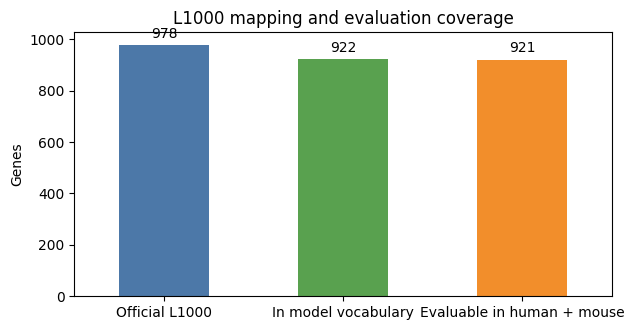

In [2]:
display(pd.Series({
    'Official L1000 landmarks': source['source_landmarks'],
    'Model-vocabulary overlap': source['model_overlap'],
    'Jointly evaluable landmarks': panels['l1000_jointly_evaluable'],
    'Jointly observed model genes': panels['jointly_observed_genes'],
    'Human discovery samples': cohorts['discovery']['samples'],
    'Human evaluation samples': cohorts['evaluation']['human']['samples'],
    'Mouse evaluation samples': cohorts['evaluation']['mouse']['samples'],
    'Discovery/evaluation GSE overlap': cohorts['discovery_evaluation_gse_overlap'],
}, name='value').to_frame())
mapping_counts = pd.Series({
    'Official L1000': source['source_landmarks'],
    'In model vocabulary': source['model_overlap'],
    'Evaluable in human + mouse': panels['l1000_jointly_evaluable'],
})
ax = mapping_counts.plot.bar(figsize=(6.5, 3.4), color=['#4C78A8', '#59A14F', '#F28E2B'])
ax.set(ylabel='Genes', title='L1000 mapping and evaluation coverage'); ax.tick_params(axis='x', rotation=0)
for container in ax.containers: ax.bar_label(container, padding=3)
plt.tight_layout(); plt.savefig(FIGURES / 'l1000_mapping_coverage.png', dpi=200, bbox_inches='tight'); plt.show()

## 2. Random-gene sufficiency curve

The final analysis reports mean ± SD across repeated fixed random panels. Pilot points contain one panel and therefore have no panel SD.

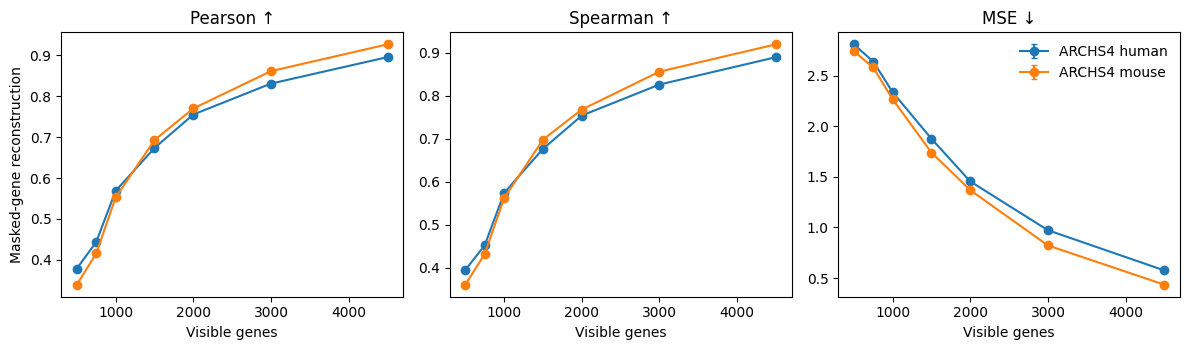

In [3]:
curve = summary[summary.panel_type.eq('random_curve')].copy()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
labels = {'archs4_holdout_human': 'ARCHS4 human', 'archs4_holdout_mouse': 'ARCHS4 mouse'}
for dataset, frame in curve.groupby('dataset'):
    frame = frame.sort_values('visible_gene_count')
    for ax, metric in zip(axes, ['pearson', 'spearman', 'mse']):
        ax.errorbar(frame.visible_gene_count, frame[f'{metric}_mean'],
                    yerr=frame[f'{metric}_sd'].fillna(0), marker='o', capsize=2, label=labels[dataset])
for ax, title in zip(axes, ['Pearson ↑', 'Spearman ↑', 'MSE ↓']): ax.set(xlabel='Visible genes', title=title)
axes[0].set_ylabel('Masked-gene reconstruction'); axes[-1].legend(frameon=False); fig.tight_layout()
fig.savefig(FIGURES / 'random_gene_sufficiency_curve.png', dpi=200, bbox_inches='tight'); plt.show()

## 3. L1000 versus size-matched random panels

dataset,panel_type,visible_gene_count,pearson_mean,pearson_sd,spearman_mean,spearman_sd,mse_mean,mse_sd,replicates,samples,masked_genes
archs4_holdout_human,l1000,921,0.562320,—,0.558050,—,2.426896,—,1,100,14243
archs4_holdout_human,random_l1000_matched,921,0.541571,—,0.546460,—,2.400131,—,1,100,14243
archs4_holdout_mouse,l1000,921,0.514466,—,0.508962,—,2.429064,—,1,100,14240
archs4_holdout_mouse,random_l1000_matched,921,0.518863,—,0.525256,—,2.351592,—,1,100,14240


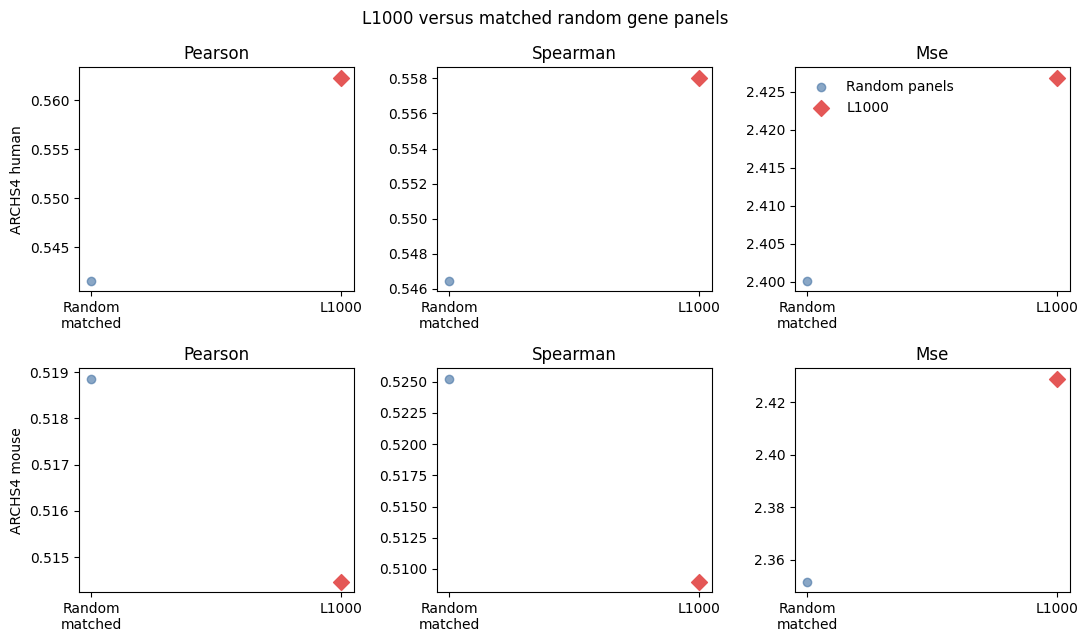

In [4]:
fixed = per_panel[per_panel.panel_type.isin(['l1000', 'random_l1000_matched'])].copy()
display(summary[summary.panel_type.isin(['l1000', 'random_l1000_matched'])]
        .style.format({c: '{:.6f}' for c in summary if c.endswith(('_mean','_sd'))}, na_rep='—').hide(axis='index'))
dataset_order = ['archs4_holdout_human', 'archs4_holdout_mouse']
fig, axes = plt.subplots(len(dataset_order), 3, figsize=(11, 6.5), squeeze=False)
for row, dataset in enumerate(dataset_order):
    frame = fixed[fixed.dataset.eq(dataset)]
    for ax, metric in zip(axes[row], ['pearson', 'spearman', 'mse']):
        random_values = frame.loc[frame.panel_type.eq('random_l1000_matched'), metric].dropna()
        l1000_values = frame.loc[frame.panel_type.eq('l1000'), metric].dropna()
        ax.scatter([0] * len(random_values), random_values, alpha=.65, color='#4C78A8', label='Random panels')
        ax.scatter([1] * len(l1000_values), l1000_values, marker='D', s=65, color='#E45756', label='L1000')
        if len(random_values) > 1:
            ax.errorbar(0, random_values.mean(), yerr=random_values.std(ddof=1), color='black', capsize=4)
        ax.set_xticks([0, 1], ['Random\nmatched', 'L1000']); ax.set_title(metric.capitalize())
        if ax is axes[row, 0]: ax.set_ylabel(labels[dataset])
axes[0, -1].legend(frameon=False, loc='best'); fig.suptitle('L1000 versus matched random gene panels')
fig.tight_layout(); fig.savefig(FIGURES / 'l1000_vs_matched_random.png', dpi=200, bbox_inches='tight'); plt.show()

## 4. L1000 advantage over matched random panels

Positive values favor L1000. For MSE, the sign is reversed so lower L1000 error appears as a positive advantage.

dataset,metric,l1000,random_mean,l1000_advantage
ARCHS4 human,pearson,0.562320,0.541571,+0.020749
ARCHS4 human,spearman,0.558050,0.546460,+0.011590
ARCHS4 human,mse,2.426896,2.400131,-0.026764
ARCHS4 mouse,pearson,0.514466,0.518863,-0.004397
ARCHS4 mouse,spearman,0.508962,0.525256,-0.016294
ARCHS4 mouse,mse,2.429064,2.351592,-0.077471


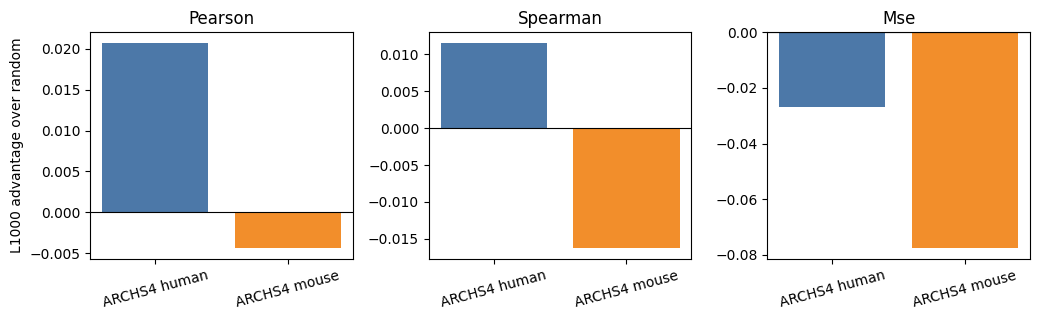

In [5]:
rows = []
for dataset in dataset_order:
    frame = fixed[fixed.dataset.eq(dataset)]
    for metric in ['pearson', 'spearman', 'mse']:
        landmark = frame.loc[frame.panel_type.eq('l1000'), metric].mean()
        random_mean = frame.loc[frame.panel_type.eq('random_l1000_matched'), metric].mean()
        advantage = random_mean - landmark if metric == 'mse' else landmark - random_mean
        rows.append({'dataset': labels[dataset], 'metric': metric, 'l1000': landmark,
                     'random_mean': random_mean, 'l1000_advantage': advantage})
advantage = pd.DataFrame(rows)
display(advantage.style.format({'l1000': '{:.6f}', 'random_mean': '{:.6f}', 'l1000_advantage': '{:+.6f}'}).hide(axis='index'))
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3))
colors = {'ARCHS4 human': '#4C78A8', 'ARCHS4 mouse': '#F28E2B'}
for ax, metric in zip(axes, ['pearson', 'spearman', 'mse']):
    frame = advantage[advantage.metric.eq(metric)]
    ax.bar(frame.dataset, frame.l1000_advantage, color=[colors[x] for x in frame.dataset])
    ax.axhline(0, color='black', linewidth=.8); ax.set_title(metric.capitalize()); ax.tick_params(axis='x', rotation=15)
axes[0].set_ylabel('L1000 advantage over random'); fig.tight_layout()
fig.savefig(FIGURES / 'l1000_advantage.png', dpi=200, bbox_inches='tight'); plt.show()

## 5. Pilot model-ranked informative genes

This exploratory ranking uses **human discovery samples only**. Four cross-fitted probe folds keep visible candidate genes separate from the genes used for scoring. The 25-sample/16-panel pilot is a screening result—not a final biological gene panel.

,value
Eligible genes,15164.0000
Genes assigned a pilot score,15164.0000
Pilot discovery samples,25.0000
Probe folds,4.0000
Panels per fold,16.0000
Visible genes per panel,921.0000
Correlation: score vs expression mean,0.0087
Correlation: score vs expression SD,-0.0095


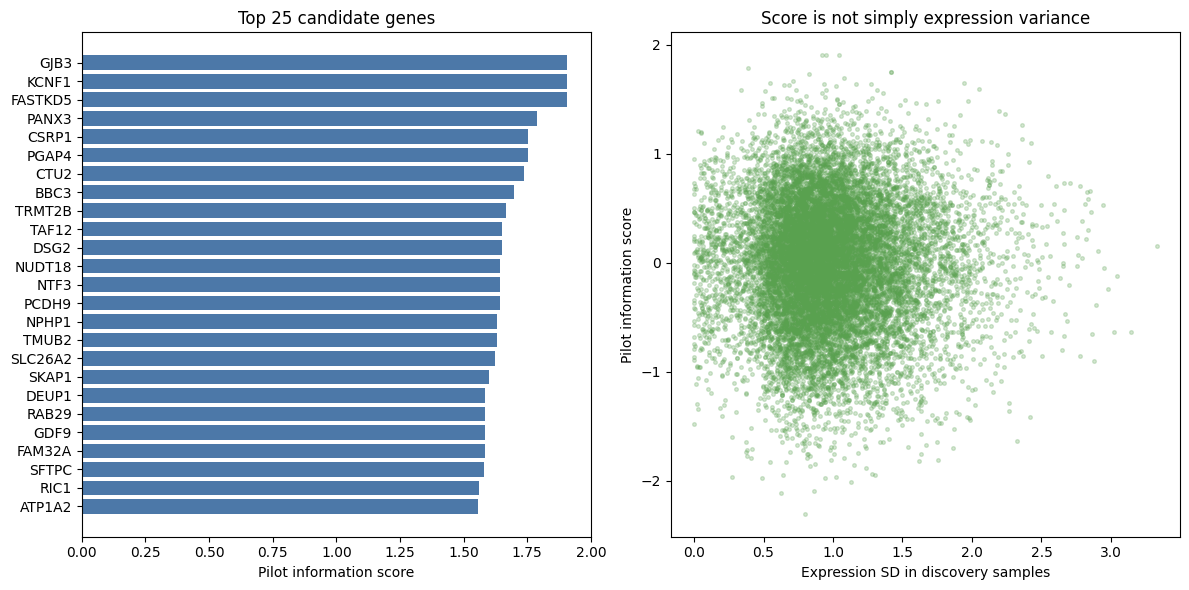

information_rank,gene,information_score,pearson_improvement,spearman_improvement,mse_improvement,expression_mean,expression_sd,detection_fraction
1,GJB3,1.905124,0.026364,0.024702,0.074483,0.614298,0.951894,0.560000
1,KCNF1,1.905124,0.026364,0.024702,0.074483,0.554957,1.041553,0.600000
1,FASTKD5,1.905124,0.026364,0.024702,0.074483,3.382034,0.923425,0.960000
4,PANX3,1.787330,0.025830,0.022980,0.071575,0.205644,0.386330,0.400000
5,CSRP1,1.751715,0.021482,0.019358,0.066512,4.593296,1.417470,1.000000
5,PGAP4,1.751715,0.021482,0.019358,0.066512,1.401091,1.413802,0.760000
7,CTU2,1.736877,0.024736,0.022478,0.070963,3.257176,0.826968,1.000000
8,BBC3,1.696799,0.019087,0.018822,0.062074,2.391710,1.076504,0.960000
9,TRMT2B,1.665250,0.024664,0.021829,0.062424,3.022632,0.709437,1.000000
10,TAF12,1.649251,0.021861,0.023394,0.058522,3.071543,0.547501,1.000000


In [6]:
ranking_path = RESULTS / 'pilot_informative_gene_ranking.parquet'
if ranking_path.is_file():
    ranking = pd.read_parquet(ranking_path)
    ranked = ranking.dropna(subset=['information_score']).copy()
    qa = pd.Series({
        'Eligible genes': int(ranking.observed.sum()),
        'Genes assigned a pilot score': len(ranked),
        'Pilot discovery samples': 25,
        'Probe folds': 4,
        'Panels per fold': 16,
        'Visible genes per panel': 921,
        'Correlation: score vs expression mean': ranked.information_score.corr(ranked.expression_mean),
        'Correlation: score vs expression SD': ranked.information_score.corr(ranked.expression_sd),
    }, name='value')
    display(qa.to_frame().style.format({'value': lambda x: f'{x:.4f}' if isinstance(x, float) else f'{x:,}'}))
    top = ranked.nsmallest(25, 'information_rank').sort_values('information_score')
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].barh(top.gene, top.information_score, color='#4C78A8')
    axes[0].set(xlabel='Pilot information score', title='Top 25 candidate genes')
    axes[1].scatter(ranked.expression_sd, ranked.information_score, s=7, alpha=.25, color='#59A14F')
    axes[1].set(xlabel='Expression SD in discovery samples', ylabel='Pilot information score',
                title='Score is not simply expression variance')
    fig.tight_layout(); fig.savefig(FIGURES / 'pilot_informative_gene_ranking.png', dpi=200, bbox_inches='tight'); plt.show()
    display(ranked.nsmallest(25, 'information_rank')[['information_rank', 'gene', 'information_score',
        'pearson_improvement', 'spearman_improvement', 'mse_improvement',
        'expression_mean', 'expression_sd', 'detection_fraction']].style.format(precision=6).hide(axis='index'))
else:
    print('Pilot ranking not found. Run pipeline/prepare_discovery_expression.py and pipeline/rank_informative_genes.py.')

## 6. Definitive cross-species informative-gene analysis

The definitive runner ranks genes independently using 500 samples from 500 distinct unseen studies per species. The score is a custom combined standardized marginal reconstruction-improvement statistic—not mutual information.

comparison,genes_a,genes_b,overlap,jaccard,expected_overlap,enrichment,hypergeometric_p,pearson_score_correlation,spearman_rank_correlation
human_top921_vs_l1000,921,921,59,0.0331,55.93,1.055,0.352,—,—
mouse_top921_vs_l1000,921,921,55,0.0308,55.93,0.983,0.574,—,—
human_top921_vs_mouse_top921,921,921,475,0.3475,55.93,8.492,0,0.7979,0.7845


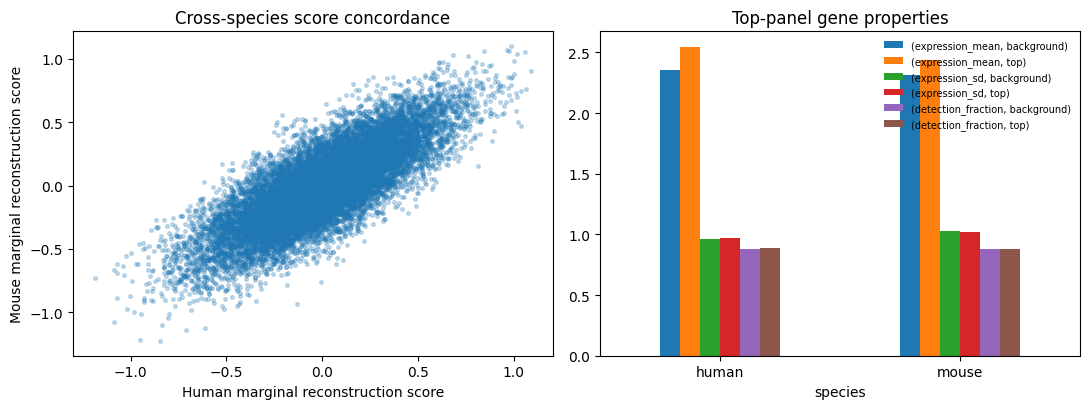

Top 25 — human


information_rank,gene,information_score,pearson_improvement,spearman_improvement,mse_improvement,expression_mean,expression_sd,detection_fraction
1,TRPV2,1.091213,0.014336,0.011949,0.039616,2.268333,1.839276,0.948000
2,PLK3,1.064723,0.014868,0.012105,0.039462,3.308136,1.022426,1.000000
3,GFPT1,1.056540,0.015323,0.012471,0.039002,3.792145,0.887217,1.000000
4,IKZF1,1.039614,0.013610,0.013010,0.035417,1.417531,1.924049,0.756000
5,NRP1,1.037173,0.013576,0.012557,0.036730,2.751464,1.523447,1.000000
6,PPP1R1A,1.020867,0.013647,0.014326,0.033544,0.633364,1.170740,0.606000
7,EIF1AD,1.015997,0.012760,0.011345,0.035720,3.373047,0.563442,1.000000
8,PRMT5,1.014955,0.013913,0.010908,0.040096,4.684454,1.087366,0.990000
9,TBXAS1,1.013704,0.013375,0.012089,0.037024,1.737854,1.406684,0.974000
10,LIMA1,1.009106,0.012213,0.010826,0.038094,3.849569,1.243720,1.000000


Top 25 — mouse


information_rank,gene,information_score,pearson_improvement,spearman_improvement,mse_improvement,expression_mean,expression_sd,detection_fraction
1,GCA,1.100749,0.015565,0.015157,0.037306,1.966993,1.058797,0.978000
2,ARPC5,1.070495,0.016383,0.012163,0.043223,5.431593,0.947187,1.000000
3,B3GNTL1,1.065601,0.016194,0.012973,0.036065,1.963295,0.757006,0.988000
4,COMTD1,1.059305,0.016747,0.012818,0.037627,2.459998,0.839007,0.992000
5,GFPT1,1.055829,0.015650,0.012695,0.043699,3.402992,0.941270,1.000000
6,EIF1AD,1.037305,0.014549,0.012611,0.038054,3.662822,0.716231,0.998000
7,ESM1,1.034102,0.015249,0.012206,0.035345,0.914273,1.185615,0.756000
8,NFIA,1.021390,0.015051,0.011026,0.040676,2.532811,1.356211,1.000000
9,LRRCC1,0.979502,0.015541,0.013008,0.035009,2.287020,0.833556,0.998000
10,PSMB4,0.974634,0.015398,0.011875,0.034270,5.692866,0.726036,0.998000


In [7]:
final_paths = {species: RESULTS / f'definitive_{species}_informative_gene_ranking.parquet' for species in ['human', 'mouse']}
overlap_path = RESULTS / 'definitive_informative_gene_overlap_summary.parquet'
property_path = RESULTS / 'definitive_informative_gene_property_summary.parquet'
if all(path.is_file() for path in final_paths.values()) and overlap_path.is_file():
    final_rankings = {species: pd.read_parquet(path) for species, path in final_paths.items()}
    overlap_summary = pd.read_parquet(overlap_path)
    property_summary = pd.read_parquet(property_path)
    display(overlap_summary.style.format({
        'jaccard': '{:.4f}', 'expected_overlap': '{:.2f}', 'enrichment': '{:.3f}',
        'hypergeometric_p': '{:.3g}', 'pearson_score_correlation': '{:.4f}',
        'spearman_rank_correlation': '{:.4f}'}, na_rep='—').hide(axis='index'))
    merged = final_rankings['human'][['model_index', 'gene', 'information_score']].merge(
        final_rankings['mouse'][['model_index', 'information_score']], on='model_index',
        suffixes=('_human', '_mouse')).dropna()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    axes[0].scatter(merged.information_score_human, merged.information_score_mouse, s=7, alpha=.25)
    axes[0].set(xlabel='Human marginal reconstruction score', ylabel='Mouse marginal reconstruction score',
                title='Cross-species score concordance')
    plot_props = property_summary.pivot(index='species', columns='group', values=['expression_mean', 'expression_sd', 'detection_fraction'])
    plot_props.plot.bar(ax=axes[1]); axes[1].set_title('Top-panel gene properties'); axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(fontsize=7, frameon=False); fig.tight_layout()
    fig.savefig(FIGURES / 'definitive_cross_species_informative_genes.png', dpi=200, bbox_inches='tight'); plt.show()
    for species, frame in final_rankings.items():
        print(f'Top 25 — {species}')
        display(frame.nsmallest(25, 'information_rank')[['information_rank', 'gene', 'information_score',
            'pearson_improvement', 'spearman_improvement', 'mse_improvement',
            'expression_mean', 'expression_sd', 'detection_fraction']].style.format(precision=6).hide(axis='index'))
else:
    missing = [path.name for path in [*final_paths.values(), overlap_path, property_path] if not path.is_file()]
    print('Definitive cross-species run is pending. Missing:', ', '.join(missing))

### Probe/visible leakage QA

For every species, fold, and panel, assert that no probe gene is visible in the input used to score that probe fold. This is design validation only and performs no model inference.

In [8]:
pipeline_dir = HERE / 'pipeline'
if str(pipeline_dir) not in sys.path: sys.path.insert(0, str(pipeline_dir))
from rank_informative_genes import build_design, seeded_rng
config = json.loads((HERE / 'config.json').read_text())
settings = config['information_density_final']
qa_rows = []
for species in ['human', 'mouse']:
    genes = pd.read_parquet(HERE / 'work' / f'{species}_information_discovery_genes.parquet')
    eligible = np.flatnonzero(genes.observed.to_numpy(bool))
    folds = int(settings['probe_folds'])
    design, visible_panels = build_design(eligible, folds, int(settings['panels_per_fold']), int(settings['visible_genes']))
    probe_folds = np.array_split(seeded_rng('probe-folds').permutation(eligible), folds)
    overlaps = []
    for condition in design.itertuples(index=False):
        overlap = np.intersect1d(probe_folds[condition.fold], visible_panels[(condition.fold, condition.replicate)])
        assert overlap.size == 0, (species, condition.fold, condition.replicate, overlap.tolist())
        overlaps.append(overlap.size)
    qa_rows.append({'species': species, 'eligible_genes': len(eligible), 'conditions_checked': len(overlaps),
                    'maximum_probe_visible_overlap': max(overlaps), 'status': 'PASS'})
display(pd.DataFrame(qa_rows).style.hide(axis='index'))

species,eligible_genes,conditions_checked,maximum_probe_visible_overlap,status
human,15165,256,0,PASS
mouse,15165,256,0,PASS


## 7. External TCGA and OSDR panel validation

Frozen Human/Mouse Top-921 and Bottom-921 panels are compared with L1000 and 50 deterministic Random-921 panels. TCGA is the external human dataset and OSDR is the external mouse dataset. Metrics are computed only over masked genes genuinely measured by each source.

dataset,panel,pearson_mean,pearson_sd,spearman_mean,spearman_sd,mse_mean,mse_sd,replicates
osdr_mouse,Random-451,0.323682,0.013785,0.341044,0.012866,2.732555,0.021778,50
osdr_mouse,Shared-451,0.394478,—,0.401897,—,2.617332,—,1
osdr_mouse,Random-921,0.516194,0.014744,0.526725,0.013774,2.325173,0.037833,50
osdr_mouse,Mouse Bottom-921,0.430361,—,0.444205,—,2.512325,—,1
osdr_mouse,Human Bottom-921,0.463026,—,0.474953,—,2.460602,—,1
osdr_mouse,Mouse Top-921,0.599792,—,0.609274,—,2.107936,—,1
osdr_mouse,Human Top-921,0.573613,—,0.584998,—,2.179046,—,1
osdr_mouse,L1000-921,0.510602,—,0.512447,—,2.401167,—,1
tcga_human,Random-451,0.350749,0.016597,0.363553,0.015030,2.584359,0.026996,50
tcga_human,Shared-451,0.417586,—,0.416173,—,2.464502,—,1


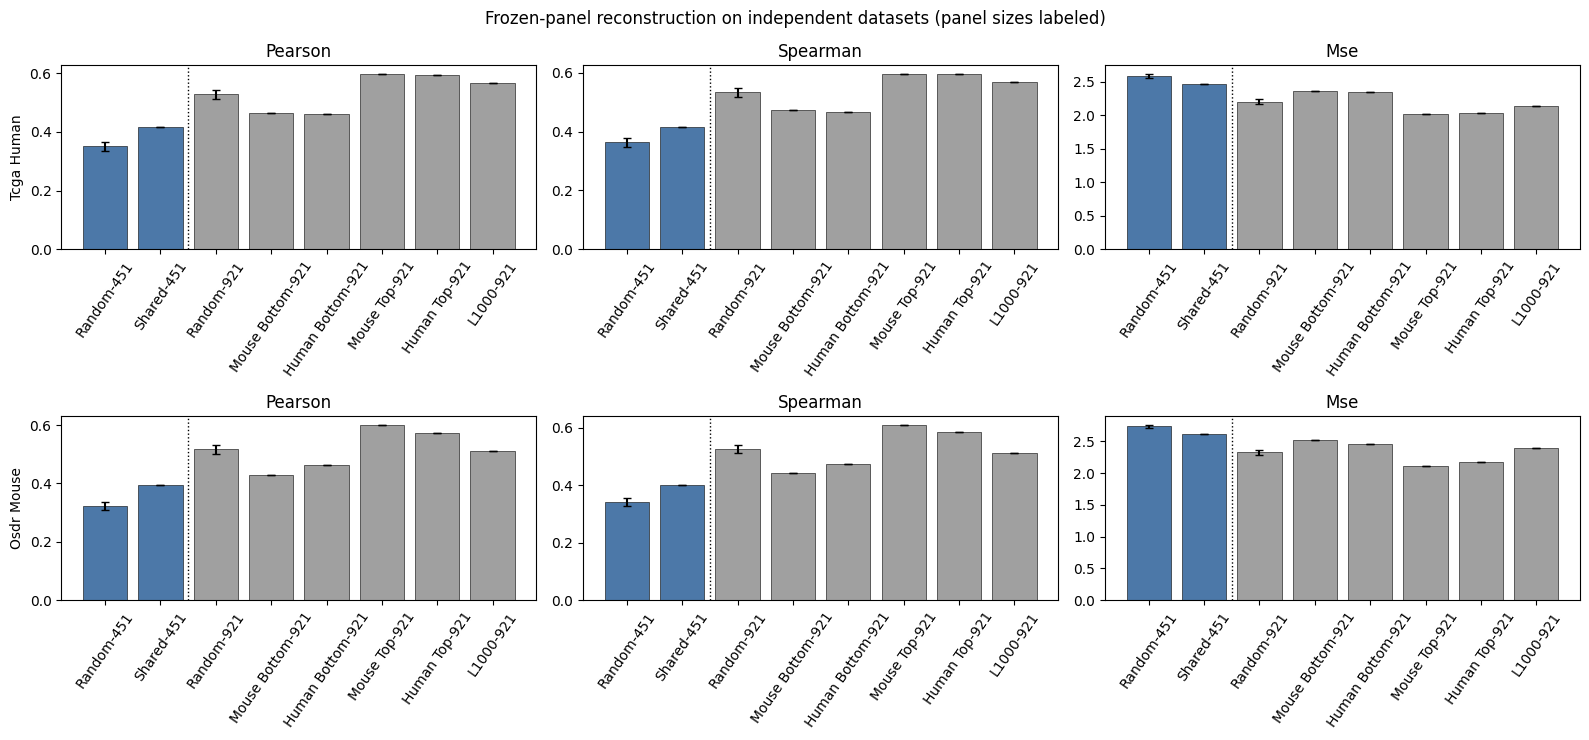

In [9]:
external_summary_path = RESULTS / 'external_panel_validation_summary.parquet'
external_panel_path = RESULTS / 'external_panel_validation_per_panel.parquet'
if external_summary_path.is_file():
    external_summary = pd.read_parquet(external_summary_path)
    external_panels = pd.read_parquet(external_panel_path)
    external_summary['panel'] = external_summary.apply(lambda row: 'Random-921' if row.panel_type == 'random' else
        ('L1000-921' if row.panel_type == 'l1000' else f'{row.selection_species.title()} {row.panel_type.title()}-921'), axis=1)
    combined_external = external_summary.copy()
    shared_summary_path = RESULTS / 'shared_451_external_validation_summary.parquet'
    if shared_summary_path.is_file():
        shared_summary_for_plot = pd.read_parquet(shared_summary_path)
        shared_summary_for_plot['panel'] = shared_summary_for_plot.panel_type.map({
            'shared_451': 'Shared-451', 'random_451': 'Random-451'})
        combined_external = pd.concat([combined_external, shared_summary_for_plot], ignore_index=True, sort=False)
    panel_order = ['Random-451', 'Shared-451', 'Random-921', 'Mouse Bottom-921',
                   'Human Bottom-921', 'Mouse Top-921', 'Human Top-921', 'L1000-921']
    combined_external['panel'] = pd.Categorical(combined_external.panel, categories=panel_order, ordered=True)
    combined_external = combined_external[combined_external.panel.notna()].copy()
    combined_table = combined_external.sort_values(['dataset', 'panel'])[[
        'dataset', 'panel', 'pearson_mean', 'pearson_sd', 'spearman_mean', 'spearman_sd',
        'mse_mean', 'mse_sd', 'replicates']]
    display(combined_table.style.format({c: '{:.6f}' for c in combined_table if c.endswith(('_mean', '_sd'))},
        na_rep='—').hide(axis='index'))
    fig, axes = plt.subplots(2, 3, figsize=(16, 7.5), squeeze=False)
    for row_index, dataset in enumerate(['tcga_human', 'osdr_mouse']):
        frame = combined_external[combined_external.dataset.eq(dataset)].sort_values('panel')
        for ax, metric in zip(axes[row_index], ['pearson', 'spearman', 'mse']):
            colors = ['#A0A0A0' if str(panel).endswith('-921') else '#4C78A8' for panel in frame.panel]
            ax.bar(frame.panel.astype(str), frame[f'{metric}_mean'], yerr=frame[f'{metric}_sd'].fillna(0),
                   capsize=3, color=colors, edgecolor='black', linewidth=.4)
            if {'Shared-451', 'Random-451'}.issubset(set(frame.panel.astype(str))): ax.axvline(1.5, color='black', linestyle=':', linewidth=1)
            ax.set_title(metric.capitalize()); ax.tick_params(axis='x', rotation=55)
            if ax is axes[row_index, 0]: ax.set_ylabel(dataset.replace('_', ' ').title())
    fig.suptitle('Frozen-panel reconstruction on independent datasets (panel sizes labeled)'); fig.tight_layout()
    fig.savefig(FIGURES / 'external_panel_validation.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print('External validation results are pending. Run pipeline/run_external_panel_validation.py.')

### 7.1 Size-matched Shared-451 validation

The frozen Shared-451 panel is compared with 50 deterministic Random-451 panels. This is a separate, equal-size test; its values should not be compared directly with the 921-visible-gene panel results above. Error bars summarize variation across random panels, while the Shared-451 panel is fixed.

dataset,metric,shared_451,random_451_mean,random_451_sd,directional_advantage,standardized_advantage,shared_451_percentile,empirical_one_sided_p,random_replicates,higher_is_better
osdr_mouse,pearson,0.394478,0.323682,0.013785,+0.070796,+5.136,100.0%,0.0196,50,True
osdr_mouse,spearman,0.401897,0.341044,0.012866,+0.060853,+4.730,100.0%,0.0196,50,True
osdr_mouse,mse,2.617332,2.732555,0.021778,+0.115223,+5.291,100.0%,0.0196,50,False
tcga_human,pearson,0.417586,0.350749,0.016597,+0.066837,+4.027,100.0%,0.0196,50,True
tcga_human,spearman,0.416173,0.363553,0.015030,+0.052620,+3.501,100.0%,0.0196,50,True
tcga_human,mse,2.464502,2.584359,0.026996,+0.119857,+4.440,100.0%,0.0196,50,False


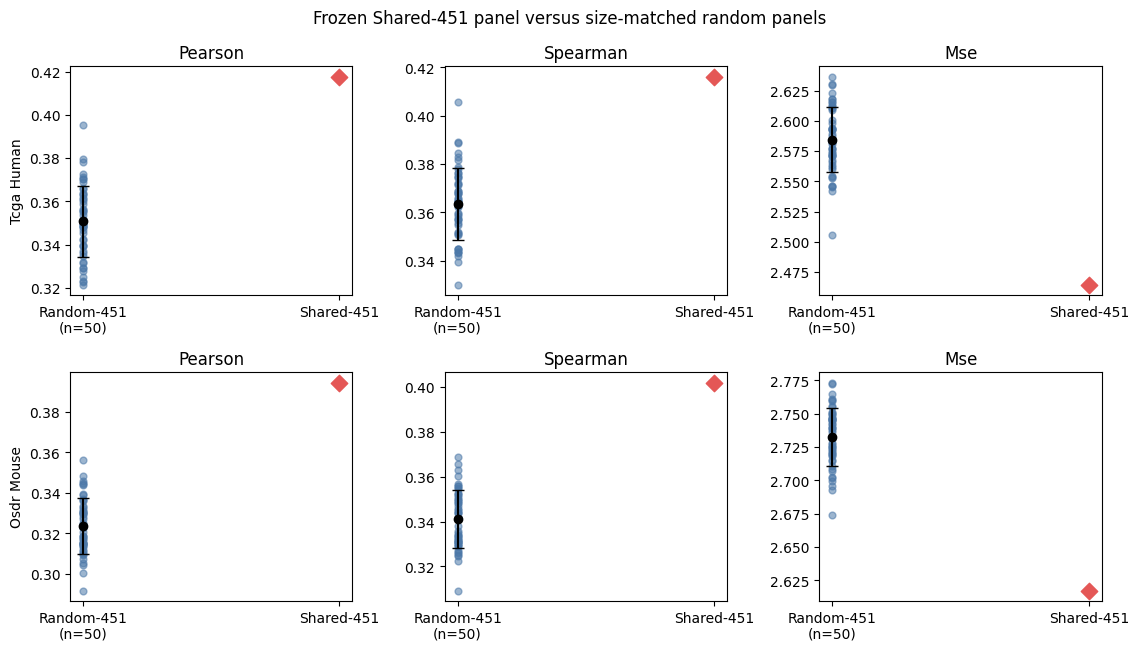

In [10]:
shared_comparison_path = RESULTS / 'shared_451_external_validation_comparison.parquet'
shared_panels_path = RESULTS / 'shared_451_external_validation_per_panel.parquet'
if shared_comparison_path.is_file() and shared_panels_path.is_file():
    shared_comparison = pd.read_parquet(shared_comparison_path)
    shared_validation_panels = pd.read_parquet(shared_panels_path)
    display(shared_comparison.style.format({
        'shared_451': '{:.6f}', 'random_451_mean': '{:.6f}', 'random_451_sd': '{:.6f}',
        'directional_advantage': '{:+.6f}', 'standardized_advantage': '{:+.3f}',
        'shared_451_percentile': '{:.1%}', 'empirical_one_sided_p': '{:.4f}'
    }, na_rep='—').hide(axis='index'))
    fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.6), squeeze=False)
    for row_index, dataset in enumerate(['tcga_human', 'osdr_mouse']):
        frame = shared_validation_panels[shared_validation_panels.dataset.eq(dataset)]
        for ax, metric in zip(axes[row_index], ['pearson', 'spearman', 'mse']):
            random_values = frame.loc[frame.panel_type.eq('random_451'), metric].dropna()
            shared_values = frame.loc[frame.panel_type.eq('shared_451'), metric].dropna()
            ax.scatter(np.zeros(len(random_values)), random_values, alpha=.55, s=24, color='#4C78A8')
            ax.errorbar(0, random_values.mean(), yerr=random_values.std(ddof=1), fmt='o', color='black', capsize=4)
            ax.scatter([1], [shared_values.iloc[0]], marker='D', s=70, color='#E45756')
            ax.set_xticks([0, 1], ['Random-451\n(n=50)', 'Shared-451'])
            ax.set_title(metric.capitalize())
            if ax is axes[row_index, 0]: ax.set_ylabel(dataset.replace('_', ' ').title())
    fig.suptitle('Frozen Shared-451 panel versus size-matched random panels')
    fig.tight_layout(); fig.savefig(FIGURES / 'shared_451_external_validation.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print('Shared-451 validation results are pending.')

### 7.2 Exploratory per-gene reconstruction

For each frozen panel, every masked, observed gene is scored across the 1,000 external samples. Pearson and Spearman therefore measure whether the model recovers between-sample variation for an individual gene; MSE measures its absolute reconstruction error. Random-451 and Random-921 use deterministic replicate 0 only. No genes were reranked and no new panels were constructed.

dataset,panel,genes_scored,samples,pearson_mean,pearson_median,spearman_mean,spearman_median,mse_mean,mse_median
osdr_mouse,Random-451,14704,1000,0.282435,0.331181,0.283463,0.338281,2.736260,2.184825
osdr_mouse,Shared-451,14704,1000,0.272545,0.318468,0.268501,0.316643,2.617332,2.103112
osdr_mouse,Random-921,14235,1000,0.390692,0.454396,0.380956,0.449154,2.309826,1.789955
osdr_mouse,Mouse Bottom-921,14234,1000,0.352932,0.415437,0.342781,0.409954,2.512325,1.892954
osdr_mouse,Human Bottom-921,14235,1000,0.357920,0.423750,0.343689,0.411703,2.460602,1.877860
osdr_mouse,Mouse Top-921,14234,1000,0.400094,0.468877,0.383484,0.452824,2.107935,1.651287
osdr_mouse,Human Top-921,14234,1000,0.386914,0.455644,0.373327,0.440888,2.179046,1.684402
osdr_mouse,L1000-921,14234,1000,0.372384,0.425773,0.366095,0.418201,2.401167,1.759383
tcga_human,Random-451,14655,1000,0.188516,0.199183,0.178030,0.191899,2.571267,1.821011
tcga_human,Shared-451,14654,1000,0.192045,0.193785,0.180620,0.187084,2.464504,1.767501


/tmp/ipykernel_51230/763339906.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=per_gene_order, showfliers=False, widths=.65)
/tmp/ipykernel_51230/763339906.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=per_gene_order, showfliers=False, widths=.65)
/tmp/ipykernel_51230/763339906.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=per_gene_order, showfliers=False, widths=.65)
/tmp/ipykernel_51230/763339906.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

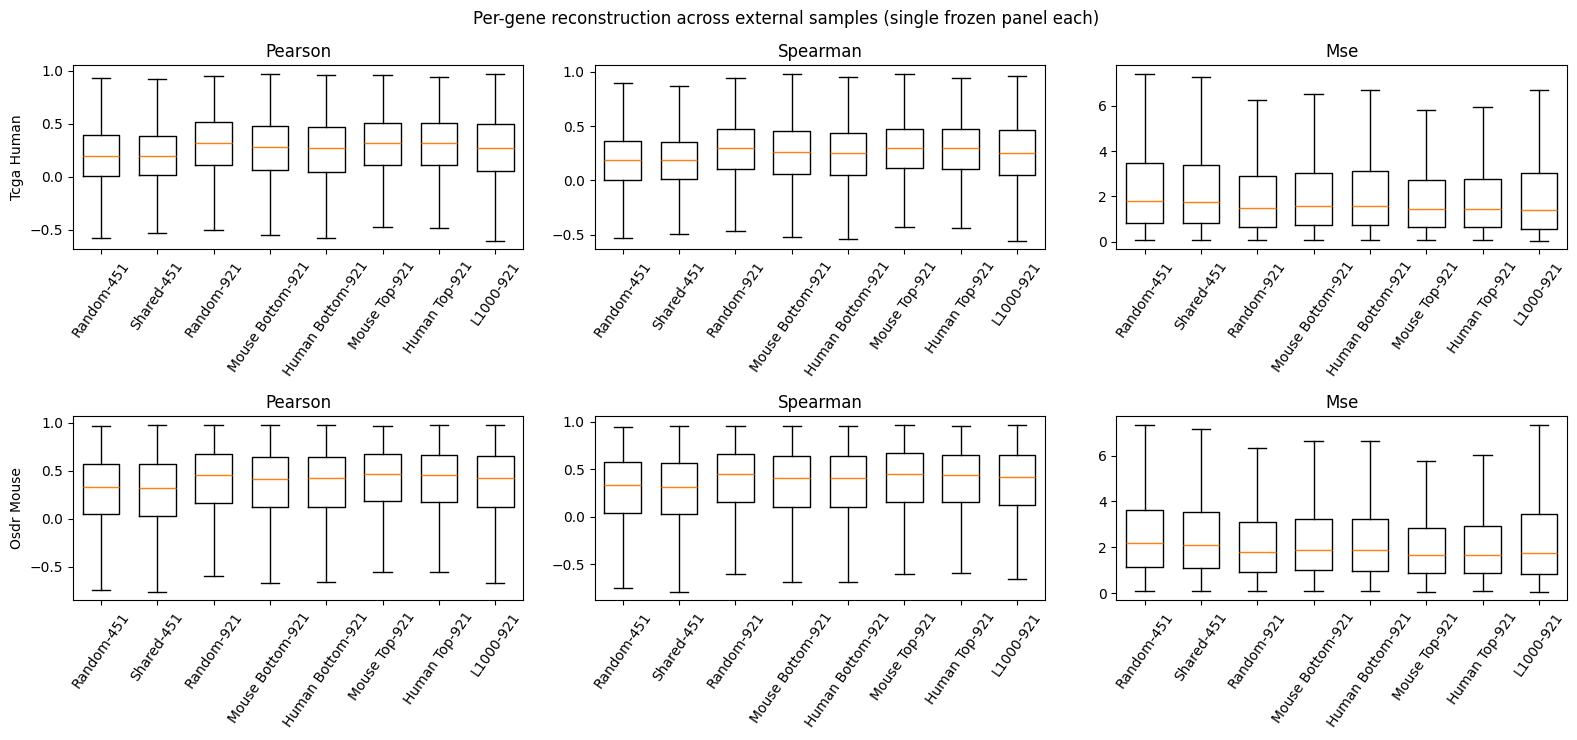

In [11]:
per_gene_path = RESULTS / 'external_per_gene_results.parquet'
per_gene_summary_path = RESULTS / 'external_per_gene_summary.parquet'
if per_gene_path.is_file() and per_gene_summary_path.is_file():
    external_per_gene = pd.read_parquet(per_gene_path)
    per_gene_summary = pd.read_parquet(per_gene_summary_path)
    per_gene_labels = {'random_451_r00': 'Random-451', 'shared_451': 'Shared-451',
        'random_921_r00': 'Random-921', 'mouse_bottom': 'Mouse Bottom-921',
        'human_bottom': 'Human Bottom-921', 'mouse_top': 'Mouse Top-921',
        'human_top': 'Human Top-921', 'l1000': 'L1000-921'}
    per_gene_order = ['Random-451', 'Shared-451', 'Random-921', 'Mouse Bottom-921',
        'Human Bottom-921', 'Mouse Top-921', 'Human Top-921', 'L1000-921']
    per_gene_summary['panel'] = pd.Categorical(per_gene_summary.panel_id.map(per_gene_labels),
        categories=per_gene_order, ordered=True)
    summary_columns = ['dataset', 'panel', 'genes_scored', 'samples', 'pearson_mean', 'pearson_median',
        'spearman_mean', 'spearman_median', 'mse_mean', 'mse_median']
    display(per_gene_summary.sort_values(['dataset', 'panel'])[summary_columns].style.format(
        {column: '{:.6f}' for column in summary_columns if column.endswith(('_mean', '_median'))}).hide(axis='index'))
    external_per_gene['panel'] = pd.Categorical(external_per_gene.panel_id.map(per_gene_labels),
        categories=per_gene_order, ordered=True)
    fig, axes = plt.subplots(2, 3, figsize=(16, 7.5), squeeze=False)
    for row_index, dataset in enumerate(['tcga_human', 'osdr_mouse']):
        frame = external_per_gene[external_per_gene.dataset.eq(dataset)]
        for ax, metric in zip(axes[row_index], ['pearson', 'spearman', 'mse']):
            values = [frame.loc[frame.panel.eq(panel), metric].dropna().to_numpy() for panel in per_gene_order]
            ax.boxplot(values, labels=per_gene_order, showfliers=False, widths=.65)
            ax.set_title(metric.capitalize()); ax.tick_params(axis='x', rotation=55)
            if ax is axes[row_index, 0]: ax.set_ylabel(dataset.replace('_', ' ').title())
    fig.suptitle('Per-gene reconstruction across external samples (single frozen panel each)')
    fig.tight_layout(); fig.savefig(FIGURES / 'external_per_gene_reconstruction.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print('Per-gene external evaluation results are pending.')

### 7.3 Exploratory gene-inference ranking

This separate ranking asks which visible genes improve prediction of each masked gene **across biological samples**, rather than whole-profile reconstruction within samples. Human and mouse discovery each used 500 ARCHS4 samples from 500 distinct unseen studies. The complete 15,165-gene vocabulary was ranked independently with 500 and 1,000 genes visible; no Top-1000 panel has been frozen from these exploratory results.

Primary result: reconstruction performance at each visible-gene count


species,visible_genes,conditions,samples,pearson_mean,pearson_sd,spearman_mean,spearman_sd,mse_mean,mse_sd
human,500,96,500,0.265510,0.010112,0.213766,0.009687,2.904124,0.062866
human,1000,96,500,0.380716,0.008744,0.320247,0.008930,2.444245,0.056551
mouse,500,96,500,0.275504,0.010841,0.262412,0.011712,2.837102,0.057536
mouse,1000,96,500,0.401685,0.009439,0.380345,0.009338,2.347400,0.059359


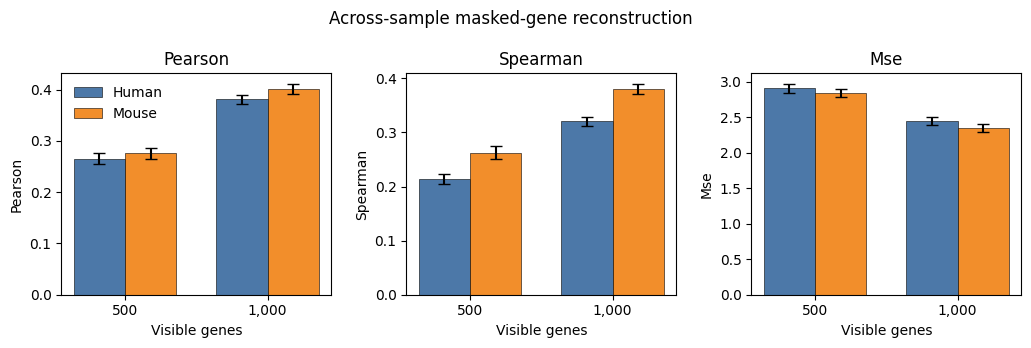

Secondary diagnostic: agreement between complete gene-utility rankings


comparison,comparison_type,genes_compared,spearman,top_n,top_n_overlap,expected_overlap,overlap_enrichment,top_n_jaccard
human: visible 500 vs 1000,visible_size,15165,0.223,1000,168,65.9,2.55×,0.092
mouse: visible 500 vs 1000,visible_size,15165,0.247,1000,168,65.9,2.55×,0.092
human vs mouse: visible 500,cross_species,15165,0.763,1000,613,65.9,9.30×,0.442
human vs mouse: visible 1000,cross_species,15165,0.737,1000,450,65.9,6.82×,0.290
human vs mouse: size consensus,cross_species_consensus,15165,0.746,1000,487,65.9,7.39×,0.322


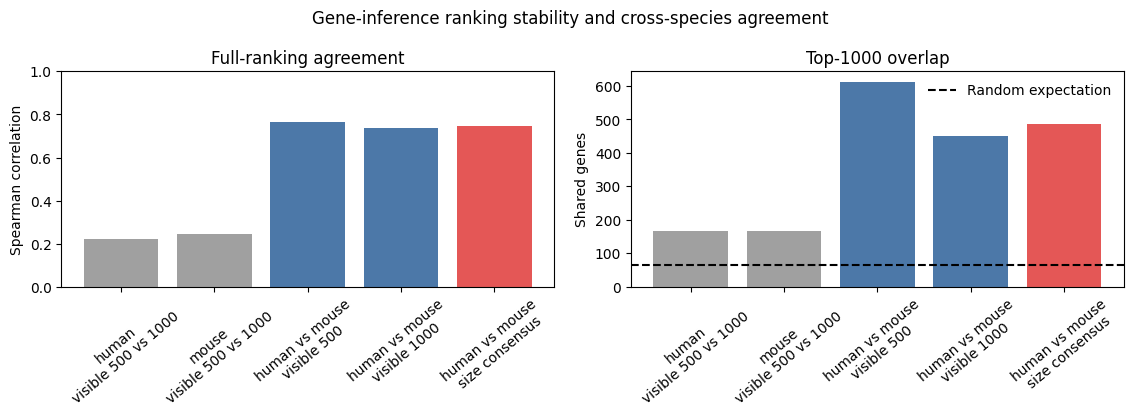

In [12]:
gene_inference_path = RESULTS / 'gene_inference_comparison_summary.parquet'
gene_inference_performance_path = RESULTS / 'gene_inference_condition_performance_summary.parquet'
if gene_inference_path.is_file() and gene_inference_performance_path.is_file():
    gene_inference_performance = pd.read_parquet(gene_inference_performance_path)
    print('Primary result: reconstruction performance at each visible-gene count')
    display(gene_inference_performance.style.format({column: '{:.6f}' for column in
        ['pearson_mean', 'pearson_sd', 'spearman_mean', 'spearman_sd', 'mse_mean', 'mse_sd']}).hide(axis='index'))
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.5))
    visible_counts = [500, 1000]; x = np.arange(len(visible_counts)); width = .36
    for ax, metric in zip(axes, ['pearson', 'spearman', 'mse']):
        for offset, (species, color) in enumerate([('human', '#4C78A8'), ('mouse', '#F28E2B')]):
            frame = (gene_inference_performance[gene_inference_performance.species.eq(species)]
                     .set_index('visible_genes').loc[visible_counts])
            positions = x + (offset - .5) * width
            ax.bar(positions, frame[f'{metric}_mean'], width, yerr=frame[f'{metric}_sd'],
                capsize=4, color=color, edgecolor='black', linewidth=.4, label=species.title())
        ax.set(xticks=x, xticklabels=['500', '1,000'], xlabel='Visible genes',
               ylabel=metric.capitalize(), title=metric.capitalize())
    axes[0].legend(frameon=False); fig.suptitle('Across-sample masked-gene reconstruction')
    fig.tight_layout(); fig.savefig(FIGURES / 'gene_inference_per_size_performance.png', dpi=200, bbox_inches='tight'); plt.show()
    print('Secondary diagnostic: agreement between complete gene-utility rankings')
    gene_inference_comparison = pd.read_parquet(gene_inference_path)
    display(gene_inference_comparison.style.format({
        'spearman': '{:.3f}', 'expected_overlap': '{:.1f}',
        'overlap_enrichment': '{:.2f}×', 'top_n_jaccard': '{:.3f}'
    }).hide(axis='index'))
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
    labels_inference = gene_inference_comparison.comparison.str.replace(': ', '\n', regex=False)
    colors_inference = gene_inference_comparison.comparison_type.map({
        'visible_size': '#A0A0A0', 'cross_species': '#4C78A8',
        'cross_species_consensus': '#E45756'})
    axes[0].bar(labels_inference, gene_inference_comparison.spearman, color=colors_inference)
    axes[0].set(ylabel='Spearman correlation', title='Full-ranking agreement', ylim=(0, 1))
    axes[1].bar(labels_inference, gene_inference_comparison.top_n_overlap, color=colors_inference)
    axes[1].axhline(gene_inference_comparison.expected_overlap.iloc[0], color='black', linestyle='--',
                    label='Random expectation')
    axes[1].set(ylabel='Shared genes', title='Top-1000 overlap'); axes[1].legend(frameon=False)
    for ax in axes: ax.tick_params(axis='x', rotation=40)
    fig.suptitle('Gene-inference ranking stability and cross-species agreement')
    fig.tight_layout(); fig.savefig(FIGURES / 'gene_inference_ranking_agreement.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print('Gene-inference ranking results are pending.')

**Interpretation.** Agreement between the 500- and 1,000-visible rankings is modest (Spearman 0.22–0.25; 168 shared Top-1000 genes), although overlap is 2.55-fold above random expectation. In contrast, human–mouse agreement is strong at both visible sizes (Spearman 0.74–0.76), with 450–613 shared Top-1000 genes. This supports a conserved gene-inference signal but also shows meaningful dependence on visible-panel size or current attribution precision. A definitive Top-1000 should therefore not be frozen until within-size reliability is quantified.

### 7.4 External validation of frozen gene-inference panels

The human, mouse, and cross-species consensus Top-1000 panels were frozen before testing on TCGA and OSDR. They are compared with 50 deterministic Random-1000 panels. L1000-All contains every official landmark that maps uniquely into the model vocabulary (922/978); it is shown as a biologically established reference but is not exactly size-matched to the 1,000-gene panels. Metrics score each masked gene across the 1,000 external samples.

dataset,panel,visible_genes,effective_visible_genes,pearson_mean,pearson_sd,spearman_mean,spearman_sd,mse_mean,mse_sd,replicates
osdr_mouse,Random-1000,1000,999,0.390562,0.009481,0.374454,0.010182,2.249585,0.030383,50
osdr_mouse,Human Top-1000,1000,1000,0.412485,—,0.395651,—,2.186723,—,1
osdr_mouse,Mouse Top-1000,1000,1000,0.425512,—,0.411507,—,2.185932,—,1
osdr_mouse,Conserved Top-1000,1000,999,0.425267,—,0.410211,—,2.177796,—,1
osdr_mouse,L1000-All (922),922,922,0.372714,—,0.366310,—,2.398358,—,1
tcga_human,Random-1000,1000,999,0.292645,0.006760,0.274783,0.006801,2.131971,0.041054,50
tcga_human,Human Top-1000,1000,996,0.315439,—,0.296818,—,2.066419,—,1
tcga_human,Mouse Top-1000,1000,997,0.312823,—,0.295043,—,2.093565,—,1
tcga_human,Conserved Top-1000,1000,997,0.325808,—,0.306730,—,2.026464,—,1
tcga_human,L1000-All (922),922,921,0.272079,—,0.254904,—,2.127097,—,1


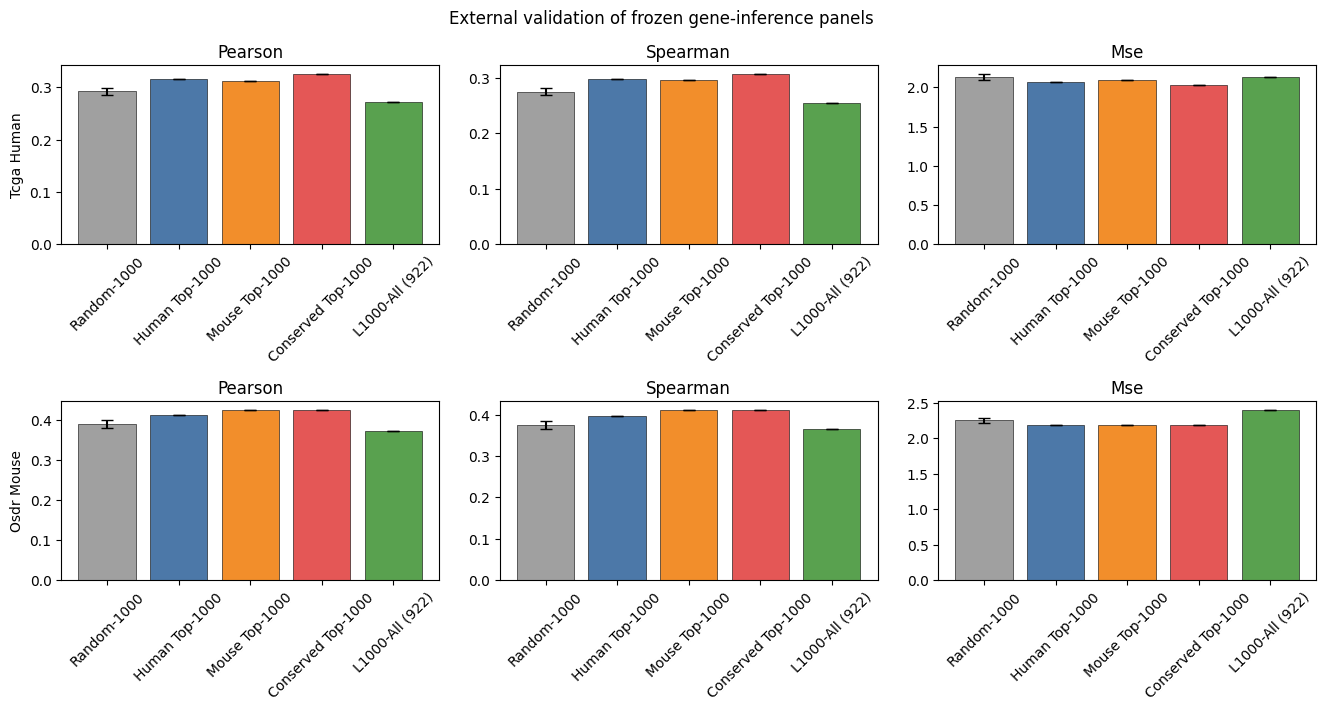

dataset,selection_species,metric,fixed_value,random_1000_mean,random_1000_sd,directional_advantage,standardized_advantage,empirical_one_sided_p
osdr_mouse,human_mouse,pearson,0.425267,0.390562,0.009481,+0.034705,+3.66,0.0196
osdr_mouse,human_mouse,spearman,0.410211,0.374454,0.010182,+0.035757,+3.51,0.0196
osdr_mouse,human_mouse,mse,2.177796,2.249585,0.030383,+0.071790,+2.36,0.0196
osdr_mouse,human,pearson,0.412485,0.390562,0.009481,+0.021923,+2.31,0.0392
osdr_mouse,human,spearman,0.395651,0.374454,0.010182,+0.021198,+2.08,0.0392
osdr_mouse,human,mse,2.186723,2.249585,0.030383,+0.062862,+2.07,0.0196
osdr_mouse,mouse,pearson,0.425512,0.390562,0.009481,+0.034950,+3.69,0.0196
osdr_mouse,mouse,spearman,0.411507,0.374454,0.010182,+0.037054,+3.64,0.0196
osdr_mouse,mouse,mse,2.185932,2.249585,0.030383,+0.063653,+2.10,0.0196
tcga_human,human_mouse,pearson,0.325808,0.292645,0.006760,+0.033163,+4.91,0.0196


In [13]:
gene_external_summary_path = RESULTS / 'gene_inference_external_validation_summary.parquet'
gene_external_comparison_path = RESULTS / 'gene_inference_external_validation_comparison.parquet'
if gene_external_summary_path.is_file() and gene_external_comparison_path.is_file():
    gene_external = pd.read_parquet(gene_external_summary_path)
    gene_external_comparison = pd.read_parquet(gene_external_comparison_path)
    gene_external['panel'] = gene_external.apply(lambda row: (
        'Random-1000' if row.panel_type == 'random_1000' else
        'L1000-All (922)' if row.panel_type == 'l1000_all_mapped' else
        'Conserved Top-1000' if row.selection_species == 'human_mouse' else
        f'{row.selection_species.title()} Top-1000'), axis=1)
    gene_external_order = ['Random-1000', 'Human Top-1000', 'Mouse Top-1000',
                           'Conserved Top-1000', 'L1000-All (922)']
    gene_external['panel'] = pd.Categorical(gene_external.panel, categories=gene_external_order, ordered=True)
    gene_external = gene_external.sort_values(['dataset', 'panel'])
    display(gene_external[['dataset', 'panel', 'visible_genes', 'effective_visible_genes',
        'pearson_mean', 'pearson_sd', 'spearman_mean', 'spearman_sd', 'mse_mean', 'mse_sd',
        'replicates']].style.format({column: '{:.6f}' for column in
        ['pearson_mean', 'pearson_sd', 'spearman_mean', 'spearman_sd', 'mse_mean', 'mse_sd']},
        na_rep='—').hide(axis='index'))
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2), squeeze=False)
    colors = ['#A0A0A0', '#4C78A8', '#F28E2B', '#E45756', '#59A14F']
    for row_index, dataset in enumerate(['tcga_human', 'osdr_mouse']):
        frame = gene_external[gene_external.dataset.eq(dataset)].sort_values('panel')
        for ax, metric in zip(axes[row_index], ['pearson', 'spearman', 'mse']):
            ax.bar(frame.panel.astype(str), frame[f'{metric}_mean'],
                yerr=frame[f'{metric}_sd'].fillna(0), capsize=4, color=colors,
                edgecolor='black', linewidth=.4)
            ax.set_title(metric.capitalize()); ax.tick_params(axis='x', rotation=45)
            if ax is axes[row_index, 0]: ax.set_ylabel(dataset.replace('_', ' ').title())
    fig.suptitle('External validation of frozen gene-inference panels')
    fig.tight_layout(); fig.savefig(FIGURES / 'gene_inference_external_validation.png', dpi=200, bbox_inches='tight'); plt.show()
    fixed_comparison = gene_external_comparison[gene_external_comparison.panel_type.eq('gene_inference_top1000')]
    display(fixed_comparison[['dataset', 'selection_species', 'metric', 'fixed_value',
        'random_1000_mean', 'random_1000_sd', 'directional_advantage',
        'standardized_advantage', 'empirical_one_sided_p']].style.format({
        'fixed_value': '{:.6f}', 'random_1000_mean': '{:.6f}', 'random_1000_sd': '{:.6f}',
        'directional_advantage': '{:+.6f}', 'standardized_advantage': '{:+.2f}',
        'empirical_one_sided_p': '{:.4f}'}).hide(axis='index'))
else:
    print('External gene-inference validation results are pending.')

**External-validation result.** All three inferred Top-1000 panels improve Pearson and Spearman over the Random-1000 distribution in both datasets. The conserved panel is strongest on TCGA and is essentially tied with the mouse-selected panel on OSDR; it also improves MSE over every random panel in both datasets (empirical one-sided *p* = 1/51). L1000-All is a 922-gene reference rather than a size-matched statistical control and performs below the Random-1000 mean for correlation in both datasets. These results support external predictive utility of the gene-inference ranking without implying that the selected genes are uniquely necessary or causal.

### 7.5 GO Biological Process and Reactome enrichment

The frozen conserved gene-inference Top-1000 panel was tested with g:Profiler against the exact 15,165-gene model universe. Sources were GO Biological Process and Reactome, using the g:SCS multiple-testing correction at 0.05.

In [14]:
gene_enrichment_summary_path = RESULTS / 'gene_inference_conserved_top1000_enrichment_summary.parquet'
gene_enrichment_path = RESULTS / 'gene_inference_conserved_top1000_enrichment.parquet'
if gene_enrichment_summary_path.is_file() and gene_enrichment_path.is_file():
    gene_enrichment_summary = pd.read_parquet(gene_enrichment_summary_path)
    gene_enrichment = pd.read_parquet(gene_enrichment_path)
    display(gene_enrichment_summary.style.hide(axis='index'))
    if gene_enrichment.empty:
        print('No GO:BP or Reactome terms passed the 0.05 g:SCS threshold.')
    else:
        display(gene_enrichment.groupby('source', group_keys=False).head(10).style.format(
            {'p_value': '{:.3e}', 'precision': '{:.3f}', 'recall': '{:.3f}'}).hide(axis='index'))
else:
    print('Gene-inference enrichment results are pending.')

source,tested_terms,significant_terms,query_genes,background_genes
GO:BP,24546,0,1000,15165
REAC,2849,0,1000,15165


No GO:BP or Reactome terms passed the 0.05 g:SCS threshold.


**Result.** No GO Biological Process or Reactome category reached corrected significance. This null enrichment is compatible with a distributed, functionally heterogeneous predictive panel; it should not be interpreted as evidence that the genes lack biological function or structure.

## 8. The frozen Shared-451 gene set

These 451 genes are the frozen overlap from the original cross-species Top-921 analysis and are retained unchanged for the prespecified GTEx tissue analysis below. The later study-balanced definitive ranking is reported separately in Section 6.

,value
Shared genes,451.000000
Also in L1000,27.000000
L1000 fraction,0.059867
Median human rank,325.000000
Median mouse rank,342.000000


gene,human_rank,mouse_rank,human_score,mouse_score,human_expression_mean,mouse_expression_mean,human_detection_fraction,mouse_detection_fraction,in_l1000,mean_rank,max_rank
COMTD1,3,1,1.032896,1.018103,3.1108,2.4177,0.992,0.990,False,2.0,3
LRRCC1,2,5,1.112920,0.874835,2.3486,2.4151,0.990,1.000,False,3.5,5
MT-ND2,14,2,0.853492,0.929592,8.6572,8.0143,0.986,1.000,False,8.0,14
CNMD,21,7,0.819269,0.850129,0.4684,1.0886,0.442,0.696,False,14.0,21
MNS1,6,25,0.907739,0.788330,2.0588,1.6522,0.974,0.962,False,15.5,25
STRIP2,5,28,0.935207,0.784943,2.2957,1.2746,0.998,0.978,False,16.5,28
CLEC3A,27,10,0.792075,0.824893,0.5702,0.1647,0.726,0.116,False,18.5,27
ASB16,12,26,0.858114,0.787613,1.2901,0.5907,0.968,0.864,False,19.0,26
CHRNA2,40,4,0.759304,0.883626,0.3861,0.8530,0.668,0.948,False,22.0,40
SYT17,16,33,0.845118,0.760773,1.2098,0.9641,0.944,0.872,False,24.5,33


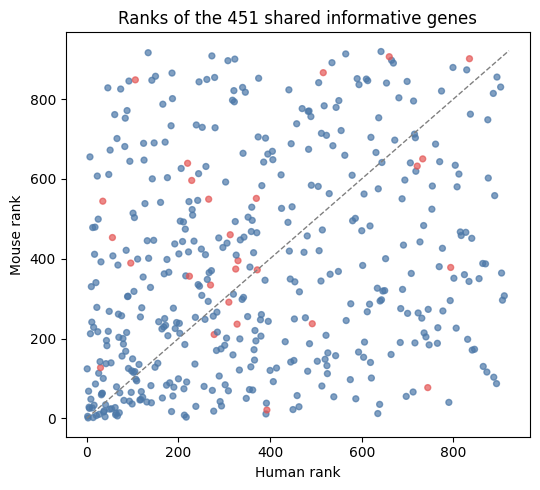

In [15]:
shared_path = RESULTS / 'shared_top_451_genes.parquet'
if shared_path.is_file():
    shared_451 = pd.read_parquet(shared_path)
    display(pd.Series({'Shared genes': len(shared_451), 'Also in L1000': int(shared_451.in_l1000.sum()),
        'L1000 fraction': shared_451.in_l1000.mean(), 'Median human rank': shared_451.human_rank.median(),
        'Median mouse rank': shared_451.mouse_rank.median()}, name='value').to_frame())
    display(shared_451.head(50).style.format({'human_score': '{:.6f}', 'mouse_score': '{:.6f}',
        'human_expression_mean': '{:.4f}', 'mouse_expression_mean': '{:.4f}',
        'human_detection_fraction': '{:.3f}', 'mouse_detection_fraction': '{:.3f}',
        'mean_rank': '{:.1f}'}).hide(axis='index'))
    fig, ax = plt.subplots(figsize=(5.5, 5))
    colors = shared_451.in_l1000.map({True: '#E45756', False: '#4C78A8'})
    ax.scatter(shared_451.human_rank, shared_451.mouse_rank, c=colors, s=18, alpha=.7)
    ax.plot([0, 921], [0, 921], '--', color='gray', linewidth=1)
    ax.set(xlabel='Human rank', ylabel='Mouse rank', title='Ranks of the 451 shared informative genes')
    fig.tight_layout(); fig.savefig(FIGURES / 'shared_451_rank_concordance.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print('Shared-gene table is pending. Run pipeline/run_gene_set_enrichment.py.')

## 9. Minimal biological interpretation

GO Biological Process and Reactome enrichment uses the complete 15,165-gene model vocabulary as the custom background. Results use g:Profiler's g:SCS multiple-testing correction; thresholds are not relaxed after inspection.

query,source,native,name,p_value,significant,term_size,query_size,intersection_size,effective_domain_size,precision,recall
human_top_921,REAC,REAC:R-HSA-8953854,Metabolism of RNA,0.0183,True,625,914,63,15246,0.0689,0.1008
shared_top_475,REAC,REAC:R-HSA-8953854,Metabolism of RNA,0.0276,True,625,471,38,15246,0.0807,0.0608
shared_top_475,REAC,REAC:R-HSA-72764,Eukaryotic Translation Termination,0.0494,True,61,471,9,15246,0.0191,0.1475
shared_top_475,REAC,REAC:R-HSA-2408557,Selenocysteine synthesis,0.0494,True,61,471,9,15246,0.0191,0.1475


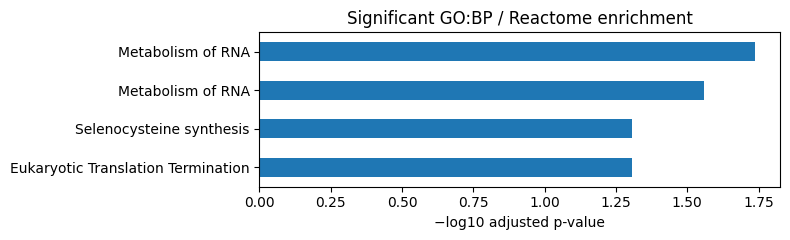

In [16]:
enrichment_path = RESULTS / 'definitive_informative_gene_enrichment.parquet'
if enrichment_path.is_file():
    enrichment = pd.read_parquet(enrichment_path)
    if enrichment.empty:
        print('No significant GO:BP or Reactome terms at the prespecified threshold.')
    else:
        display(enrichment.style.format({'p_value': '{:.3g}', 'precision': '{:.4f}', 'recall': '{:.4f}'}).hide(axis='index'))
        shown = enrichment.nsmallest(20, 'p_value').sort_values('p_value', ascending=False).copy()
        shown['minus_log10_p'] = -np.log10(shown.p_value)
        ax = shown.plot.barh(x='name', y='minus_log10_p', figsize=(8, max(2.5, len(shown) * .38)), legend=False)
        ax.set(xlabel='−log10 adjusted p-value', ylabel='', title='Significant GO:BP / Reactome enrichment')
        plt.tight_layout(); plt.savefig(FIGURES / 'informative_gene_enrichment.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print('Enrichment results are pending. Run pipeline/run_gene_set_enrichment.py.')

## 10. GTEx tissue-expression patterns of informative genes

This prespecified analysis uses 9,662 GTEx samples across 54 detailed tissue labels and is restricted to the model's 15,165-gene universe. Raw counts are normalized sample-wise to counts per million and transformed with natural `log1p`; each cell of the gene-by-tissue matrix is the within-tissue median. Tissue specificity is the maximum tissue median divided by the mean tissue median. Shared-451 is the frozen set defined in Section 8; Top-921 contains Shared-451, while the remaining/background set excludes all Top-921 genes. The complete per-gene and Shared-451 highest-tissue tables remain in `results/`.

Tissue-specificity comparison


gene_set,genes_in_set,genes_with_gtex_specificity,mean_tissue_specificity,median_tissue_specificity,tissue_specificity_q25,tissue_specificity_q75
Shared-451,451,449,3.4282,1.5120,1.2767,2.6440
Top-921,921,915,3.5210,1.5175,1.2825,2.6675
Remaining/background,14244,14114,3.8498,1.5621,1.2928,2.9206


Spearman correlation: tissue specificity versus marginal reconstruction score


genes,spearman_rho,p_value
15029,-0.0235,0.004


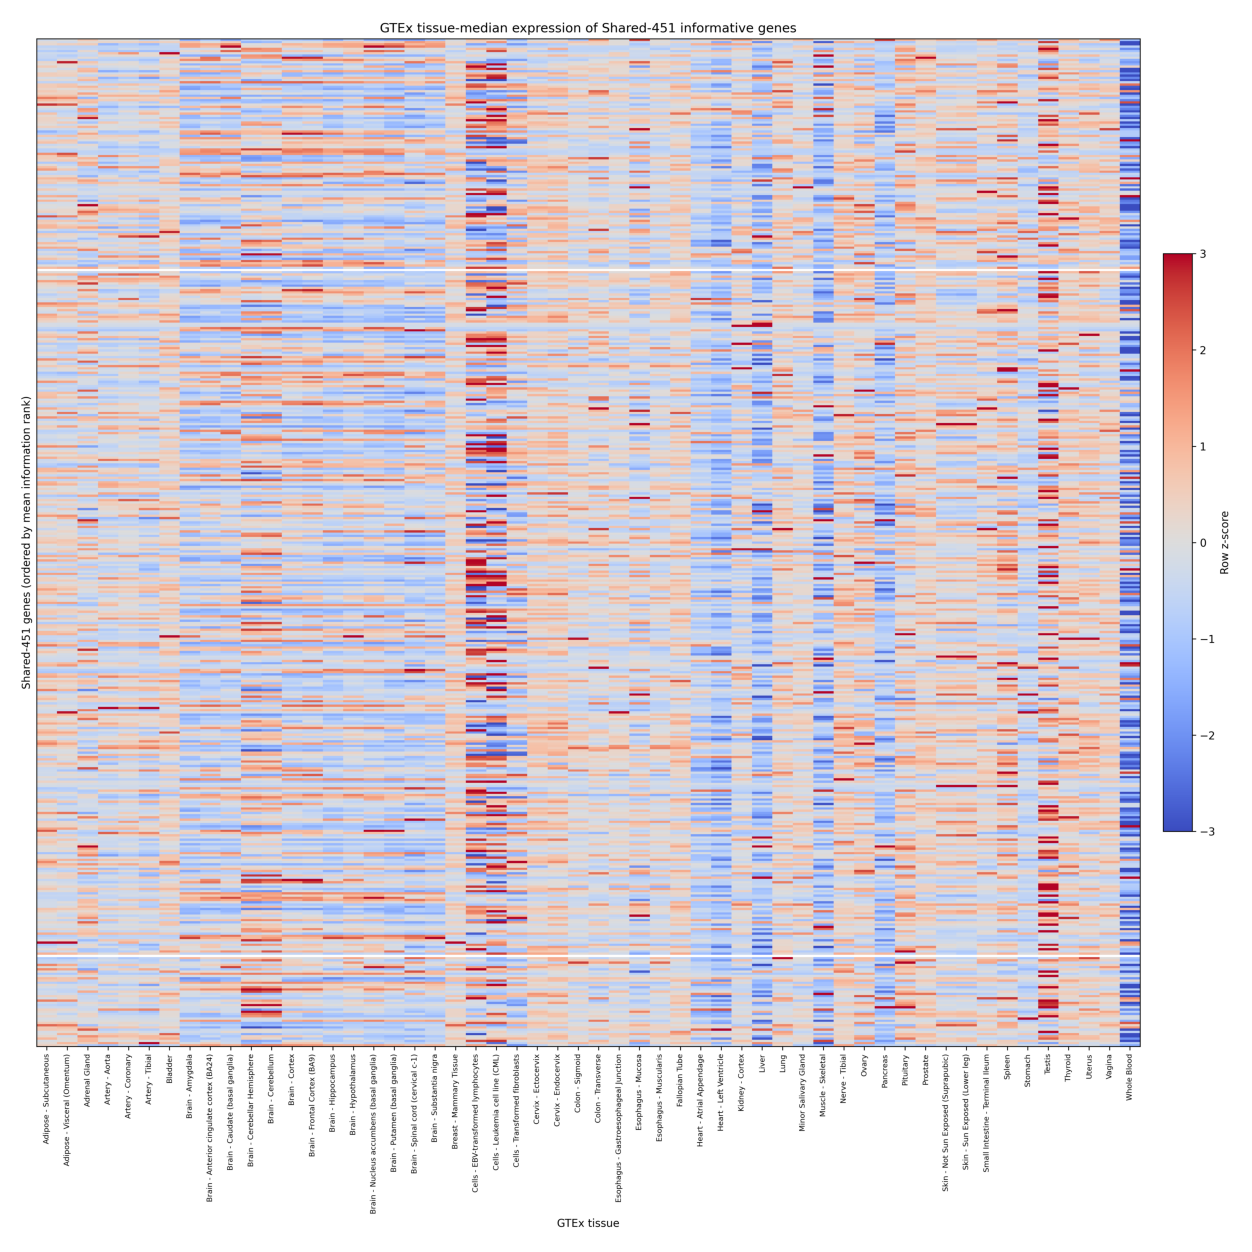

Shared-451 highest-expression GTEx tissues (first 50 by information rank; all 451 are saved in the result table)


gene,model_index,information_score,information_rank,highest_expression_tissue,maximum_tissue_median,mean_tissue_median,tissue_specificity
PPP1R1A,9953,1.143860,1,Muscle - Skeletal,5.9345,2.8395,2.0900
LRRCC1,7076,1.112920,2,Testis,4.0961,2.4581,1.6664
COMTD1,2667,1.032896,3,Pancreas,4.0174,2.3542,1.7065
MT-ND4L,7949,0.982006,4,Heart - Left Ventricle,8.7308,7.5480,1.1567
STRIP2,12702,0.935207,5,Cells - Leukemia cell line (CML),4.9074,1.8137,2.7058
MNS1,7720,0.907739,6,Testis,4.3698,1.3639,3.2038
RBM46,10667,0.899989,7,Testis,3.3373,0.1060,31.4710
PLK3,9702,0.877865,8,Artery - Aorta,3.8795,2.7982,1.3864
RAPGEF1,10570,0.865908,9,Cells - EBV-transformed lymphocytes,5.5480,4.5324,1.2241
SSTR1,12577,0.863952,10,Stomach,3.1503,1.3355,2.3590


In [17]:
gtex_group_path = RESULTS / 'gtex_tissue_specificity_group_summary.parquet'
gtex_correlation_path = RESULTS / 'gtex_tissue_specificity_score_correlation.parquet'
gtex_shared_path = RESULTS / 'gtex_shared_451_highest_expression_tissue.parquet'
gtex_heatmap_path = FIGURES / 'gtex_shared_451_tissue_heatmap.png'
required = [gtex_group_path, gtex_correlation_path, gtex_shared_path, gtex_heatmap_path]
if all(path.is_file() for path in required):
    gtex_groups = pd.read_parquet(gtex_group_path)
    gtex_correlation = pd.read_parquet(gtex_correlation_path)
    gtex_shared_tissues = pd.read_parquet(gtex_shared_path)
    print('Tissue-specificity comparison')
    display(gtex_groups.style.format({
        'mean_tissue_specificity': '{:.4f}', 'median_tissue_specificity': '{:.4f}',
        'tissue_specificity_q25': '{:.4f}', 'tissue_specificity_q75': '{:.4f}'
    }).hide(axis='index'))
    print('Spearman correlation: tissue specificity versus marginal reconstruction score')
    display(gtex_correlation.style.format({'spearman_rho': '{:.4f}', 'p_value': '{:.3g}'}).hide(axis='index'))
    image = plt.imread(gtex_heatmap_path)
    fig, ax = plt.subplots(figsize=(16, 16)); ax.imshow(image); ax.axis('off'); plt.show()
    print('Shared-451 highest-expression GTEx tissues (first 50 by information rank; all 451 are saved in the result table)')
    display(gtex_shared_tissues.head(50).style.format({
        'information_score': '{:.6f}', 'maximum_tissue_median': '{:.4f}',
        'mean_tissue_median': '{:.4f}', 'tissue_specificity': '{:.4f}'
    }, na_rep='—').hide(axis='index'))
else:
    missing = [path.name for path in required if not path.is_file()]
    print('GTEx tissue-pattern results are pending. Missing:', ', '.join(missing))

## 11. GTEx coexpression of informative genes

For each gene, Pearson correlation was calculated against every other measurable model gene across the same 9,662 GTEx samples, excluding self-correlation. The two prespecified summaries are mean absolute correlation and the number of other genes with $|r| > 0.5$. Computation used exact GPU-blocked matrix multiplication without retaining the full correlation matrix. Missing or zero-variance genes remain null in the 15,165-row result table.

In [18]:
coexpression_group_path = RESULTS / 'gtex_coexpression_group_summary.parquet'
coexpression_correlation_path = RESULTS / 'gtex_coexpression_score_correlations.parquet'
if coexpression_group_path.is_file() and coexpression_correlation_path.is_file():
    coexpression_groups = pd.read_parquet(coexpression_group_path)
    coexpression_correlations = pd.read_parquet(coexpression_correlation_path)
    print('Median GTEx coexpression measures')
    display(coexpression_groups.style.format({
        'median_mean_absolute_correlation': '{:.4f}',
        'median_correlated_genes_abs_r_gt_0_5': '{:.1f}'
    }).hide(axis='index'))
    print('Association with marginal reconstruction score')
    display(coexpression_correlations.style.format({
        'spearman_rho': '{:.4f}', 'p_value': '{:.3g}'
    }).hide(axis='index'))
    print('Conclusion: highly informative reconstruction genes are not simply more broadly coexpressed with the rest of the GTEx transcriptome.')
else:
    print('GTEx coexpression results are pending. Run pipeline/analyze_gtex_coexpression.py.')

Median GTEx coexpression measures


gene_set,genes_in_set,genes_with_coexpression,median_mean_absolute_correlation,median_correlated_genes_abs_r_gt_0_5
Shared-451,451,449,0.2333,1115.0
Top-921,921,915,0.2328,1053.0
Remaining/background,14244,14122,0.2353,1097.5


Association with marginal reconstruction score


coexpression_measure,genes,spearman_rho,p_value
mean_absolute_correlation,15037,0.0055,0.502
correlated_genes_abs_r_gt_0_5,15037,0.0065,0.428


Conclusion: highly informative reconstruction genes are not simply more broadly coexpressed with the rest of the GTEx transcriptome.


## 12. Unrounded summary table

This is the machine-readable result view. Values remain unrounded in the Parquet outputs.

In [19]:
display(summary.sort_values(['dataset','panel_type','visible_gene_count']))

,dataset,panel_type,visible_gene_count,pearson_mean,pearson_sd,spearman_mean,spearman_sd,mse_mean,mse_sd,replicates,samples,masked_genes
0,archs4_holdout_human,l1000,921,0.562320,NaN,0.558050,NaN,2.426896,NaN,1,100,14243
1,archs4_holdout_human,random_curve,500,0.378987,NaN,0.394214,NaN,2.807808,NaN,1,100,14664
2,archs4_holdout_human,random_curve,750,0.443774,NaN,0.451753,NaN,2.638262,NaN,1,100,14414
3,archs4_holdout_human,random_curve,1000,0.568649,NaN,0.573863,NaN,2.336078,NaN,1,100,14164
4,archs4_holdout_human,random_curve,1500,0.673272,NaN,0.676519,NaN,1.875970,NaN,1,100,13664
5,archs4_holdout_human,random_curve,2000,0.755101,NaN,0.754149,NaN,1.454708,NaN,1,100,13164
6,archs4_holdout_human,random_curve,3000,0.830546,NaN,0.826440,NaN,0.972964,NaN,1,100,12164
7,archs4_holdout_human,random_curve,4500,0.895202,NaN,0.890137,NaN,0.575741,NaN,1,100,10664
8,archs4_holdout_human,random_l1000_matched,921,0.541571,NaN,0.546460,NaN,2.400131,NaN,1,100,14243
9,archs4_holdout_mouse,l1000,921,0.514466,NaN,0.508962,NaN,2.429064,NaN,1,100,14240
